In [13]:
# Block 1: Imports and Data Loading

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────
DATA_DIR = r"D:\Ops\STA611\m5-forecasting-accuracy"

# ── Load files ─────────────────────────────────────────────────────────────
print("Loading sales data...")
sales = pd.read_csv(f"{DATA_DIR}\\sales_train_validation.csv")

print("Loading calendar...")
calendar = pd.read_csv(f"{DATA_DIR}\\calendar.csv")

print("Loading prices...")
prices = pd.read_csv(f"{DATA_DIR}\\sell_prices.csv")

# ── Sanity check ───────────────────────────────────────────────────────────
print(f"\n── sales shape:    {sales.shape}")
print(f"── calendar shape: {calendar.shape}")
print(f"── prices shape:   {prices.shape}")

print(f"\n── Sales columns (first 10): {list(sales.columns[:10])}")
print(f"── Sales columns (last 5):  {list(sales.columns[-5:])}")

print(f"\n── Categories in data:")
print(sales['cat_id'].value_counts())

print(f"\n── Stores in data:")
print(sales['store_id'].value_counts())

Loading sales data...
Loading calendar...
Loading prices...

── sales shape:    (30490, 1919)
── calendar shape: (1969, 14)
── prices shape:   (6841121, 4)

── Sales columns (first 10): ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id', 'd_1', 'd_2', 'd_3', 'd_4']
── Sales columns (last 5):  ['d_1909', 'd_1910', 'd_1911', 'd_1912', 'd_1913']

── Categories in data:
cat_id
FOODS        14370
HOUSEHOLD    10470
HOBBIES       5650
Name: count, dtype: int64

── Stores in data:
store_id
CA_1    3049
CA_2    3049
CA_3    3049
CA_4    3049
TX_1    3049
TX_2    3049
TX_3    3049
WI_1    3049
WI_2    3049
WI_3    3049
Name: count, dtype: int64


In [14]:
# Block 2: SKU Selection and Weekly Aggregation
# Strategy: fix one store (CA_1), aggregate daily → weekly,
# sample SKUs per category filtering out near-zero / intermittent series

STORE = "CA_1"

# ── Step 1: Filter to one store ─────────────────────────────────────────
store_sales = sales[sales['store_id'] == STORE].copy()
print(f"SKUs in {STORE}: {len(store_sales)}")

# ── Step 2: Melt to long format ─────────────────────────────────────────
day_cols = [c for c in sales.columns if c.startswith('d_')]

store_long = store_sales.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=day_cols,
    var_name='d',
    value_name='sales'
)

# ── Step 3: Merge calendar to get actual dates ───────────────────────────
store_long = store_long.merge(calendar[['d', 'date', 'wm_yr_wk']], on='d', how='left')
store_long['date'] = pd.to_datetime(store_long['date'])

# ── Step 4: Aggregate to weekly (sum daily sales within each wm_yr_wk) ──
weekly = (store_long
          .groupby(['item_id', 'cat_id', 'dept_id', 'wm_yr_wk'])['sales']
          .sum()
          .reset_index()
          .sort_values(['item_id', 'wm_yr_wk']))

print(f"Weeks in data: {weekly['wm_yr_wk'].nunique()}")
print(f"Sample weekly rows: {len(weekly)}")

# ── Step 5: Filter out intermittent SKUs ────────────────────────────────
# Keep SKUs where at least 70% of weeks have non-zero sales
total_weeks = weekly['wm_yr_wk'].nunique()

nonzero_frac = (weekly.groupby('item_id')['sales']
                .apply(lambda x: (x > 0).sum() / len(x))
                .reset_index()
                .rename(columns={'sales': 'nonzero_frac'}))

eligible = nonzero_frac[nonzero_frac['nonzero_frac'] >= 0.70]['item_id']
print(f"\nSKUs with ≥70% non-zero weeks: {len(eligible)} of {store_sales['item_id'].nunique()}")

# ── Step 6: Stratified sample — 15 SKUs per category ────────────────────
np.random.seed(42)

weekly_eligible = weekly[weekly['item_id'].isin(eligible)]

sampled_skus = (weekly_eligible
                .drop_duplicates('item_id')[['item_id', 'cat_id', 'dept_id']]
                .groupby('cat_id', group_keys=False)
                .apply(lambda x: x.sample(min(15, len(x)))))

print(f"\nSampled SKUs per category:")
print(sampled_skus['cat_id'].value_counts())
print(f"\nTotal SKUs selected: {len(sampled_skus)}")

# ── Step 7: Final working dataset ───────────────────────────────────────
analysis_df = weekly[weekly['item_id'].isin(sampled_skus['item_id'])].copy()
print(f"\nAnalysis dataframe shape: {analysis_df.shape}")
print(analysis_df.head(8))

SKUs in CA_1: 3049
Weeks in data: 274
Sample weekly rows: 835426

SKUs with ≥70% non-zero weeks: 1410 of 3049

Sampled SKUs per category:
cat_id
FOODS        15
HOBBIES      15
HOUSEHOLD    15
Name: count, dtype: int64

Total SKUs selected: 45

Analysis dataframe shape: (12330, 5)
           item_id cat_id  dept_id  wm_yr_wk  sales
16440  FOODS_1_062  FOODS  FOODS_1     11101      6
16441  FOODS_1_062  FOODS  FOODS_1     11102     12
16442  FOODS_1_062  FOODS  FOODS_1     11103      6
16443  FOODS_1_062  FOODS  FOODS_1     11104      9
16444  FOODS_1_062  FOODS  FOODS_1     11105      6
16445  FOODS_1_062  FOODS  FOODS_1     11106      7
16446  FOODS_1_062  FOODS  FOODS_1     11107      6
16447  FOODS_1_062  FOODS  FOODS_1     11108      2


In [ ]:
# Block 2b: Economic Weight of Intermittent SKUs

# Total sales per SKU across all weeks
total_sales_per_sku = weekly.groupby('item_id')['sales'].sum().reset_index()
total_sales_per_sku.columns = ['item_id', 'total_sales']

# Tag each SKU as eligible or intermittent
total_sales_per_sku['segment'] = np.where(
    total_sales_per_sku['item_id'].isin(eligible),
    'Continuous (≥70% non-zero)',
    'Intermittent (<70% non-zero)'
)

# Sales share by segment
segment_summary = (total_sales_per_sku
                   .groupby('segment')['total_sales']
                   .agg(['sum', 'count', 'mean'])
                   .reset_index())
segment_summary['sales_share_%'] = (
    100 * segment_summary['sum'] / segment_summary['sum'].sum()
).round(2)
segment_summary.columns = ['segment', 'total_sales', 'sku_count',
                            'avg_sales_per_sku', 'sales_share_%']

print("── Sales Share by Demand Continuity ─────────────────────────────")
print(segment_summary.round(1).to_string(index=False))

# ── Within intermittent: distribution of sales ───────────────────────
intermittent_sales = total_sales_per_sku[
    total_sales_per_sku['segment'] == 'Intermittent (<70% non-zero)'
]['total_sales']

print(f"\n── Intermittent SKU sales distribution ──────────────────────────")
print(f"  Median total sales: {intermittent_sales.median():.0f} units")
print(f"  90th percentile:    {intermittent_sales.quantile(0.90):.0f} units")
print(f"  Max:                {intermittent_sales.max():.0f} units")

# ── Top 10 intermittent SKUs by revenue ──────────────────────────────
top_intermittent = (total_sales_per_sku[
    total_sales_per_sku['segment'] == 'Intermittent (<70% non-zero)']
    .sort_values('total_sales', ascending=False)
    .head(10))

print(f"\n── Top 10 intermittent SKUs by total sales ───────────────────────")
print(top_intermittent.to_string(index=False))

── Sales Share by Demand Continuity ─────────────────────────────
                     segment  total_sales  sku_count  avg_sales_per_sku  sales_share_%
  Continuous (≥70% non-zero)      5829050       1410             4134.1           75.7
Intermittent (<70% non-zero)      1869166       1639             1140.4           24.3

── Intermittent SKU sales distribution ──────────────────────────
  Median total sales: 558 units
  90th percentile:    2322 units
  Max:                29272 units

── Top 10 intermittent SKUs by total sales ───────────────────────
    item_id  total_sales                      segment
FOODS_3_282        29272 Intermittent (<70% non-zero)
FOODS_3_281        22942 Intermittent (<70% non-zero)
FOODS_3_739        21890 Intermittent (<70% non-zero)
FOODS_3_362        21426 Intermittent (<70% non-zero)
FOODS_3_329        20272 Intermittent (<70% non-zero)
FOODS_3_764        19928 Intermittent (<70% non-zero)
FOODS_3_288        18793 Intermittent (<70% non-zero)
FOODS_3

In [ ]:
# Block 3: AR(1) Estimation per SKU
# Fit log1p(sales_t) ~ rho * log1p(sales_{t-1}) + intercept via OLS
# Extract rho, 95% CI, p-value, and residuals for each SKU

from scipy import stats

results = []

for item_id, grp in analysis_df.groupby('item_id'):

    grp = grp.sort_values('wm_yr_wk').reset_index(drop=True)
    cat = grp['cat_id'].iloc[0]
    dept = grp['dept_id'].iloc[0]

    # Log-transform (log1p handles any remaining zero weeks)
    log_sales = np.log1p(grp['sales'].values)

    # Build lagged series
    y = log_sales[1:]      # log(D_t)
    x = log_sales[:-1]     # log(D_{t-1})
    n = len(y)

    # OLS via scipy linregress
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

    # 95% CI for slope (rho)
    t_crit = stats.t.ppf(0.975, df=n-2)
    ci_lower = slope - t_crit * std_err
    ci_upper = slope + t_crit * std_err

    # Residuals for GOF test later
    y_hat = intercept + slope * x
    residuals = y - y_hat
    residual_std = np.std(residuals, ddof=2)

    results.append({
        'item_id':    item_id,
        'cat_id':     cat,
        'dept_id':    dept,
        'n_weeks':    n,
        'rho':        slope,
        'intercept':  intercept,
        'rho_se':     std_err,
        'ci_lower':   ci_lower,
        'ci_upper':   ci_upper,
        'p_value':    p_value,
        'r_squared':  r_value**2,
        'resid_std':  residual_std
    })

rho_df = pd.DataFrame(results)

# ── Summary ──────────────────────────────────────────────────────────────
print("── ρ Estimates by Category ──────────────────────────────────────")
print(rho_df.groupby('cat_id')['rho'].describe().round(3))

print("\n── Fraction with ρ significantly > 0 (p < 0.05) ───────────────")
sig = rho_df[rho_df['p_value'] < 0.05]
print(f"  {len(sig)} of {len(rho_df)} SKUs ({100*len(sig)/len(rho_df):.1f}%)")

print("\n── ρ range across all SKUs ──────────────────────────────────────")
print(rho_df[['rho', 'ci_lower', 'ci_upper']].describe().round(3))

print("\n── Sample of results ────────────────────────────────────────────")
print(rho_df[['item_id','cat_id','rho','ci_lower','ci_upper',
              'p_value','r_squared']].head(10).round(3))

── ρ Estimates by Category ──────────────────────────────────────
           count   mean    std    min    25%    50%    75%    max
cat_id                                                           
FOODS       15.0  0.626  0.270 -0.049  0.544  0.718  0.811  0.877
HOBBIES     15.0  0.509  0.260 -0.024  0.341  0.534  0.730  0.847
HOUSEHOLD   15.0  0.514  0.249  0.014  0.372  0.539  0.654  0.882

── Fraction with ρ significantly > 0 (p < 0.05) ───────────────
  41 of 45 SKUs (91.1%)

── ρ range across all SKUs ──────────────────────────────────────
          rho  ci_lower  ci_upper
count  45.000    45.000    45.000
mean    0.550     0.457     0.643
std     0.260     0.279     0.241
min    -0.049    -0.169     0.071
25%     0.420     0.312     0.527
50%     0.609     0.513     0.704
75%     0.755     0.677     0.833
max     0.882     0.828     0.937

── Sample of results ────────────────────────────────────────────
       item_id cat_id    rho  ci_lower  ci_upper  p_value  r_squared
0  FOO

── Levene's Test for Equal Variances ────────────────────────────
  Statistic: 0.1157
  p-value:   0.8910
  Variances homogeneous: Yes

── One-Way ANOVA: H0: μ_FOODS = μ_HOBBIES = μ_HOUSEHOLD ────────
  F-statistic: 0.9793
  p-value:     0.3840
  Result: Fail to reject H0 — no significant difference

── Effect Size ──────────────────────────────────────────────────
  η² (eta-squared): 0.0446
  Interpretation: Small (<0.06)

── Group Means and 95% CIs ──────────────────────────────────────
  FOODS       n=15  mean_ρ=0.626  95% CI [0.477, 0.776]
  HOBBIES     n=15  mean_ρ=0.509  95% CI [0.365, 0.653]
  HOUSEHOLD   n=15  mean_ρ=0.514  95% CI [0.376, 0.652]


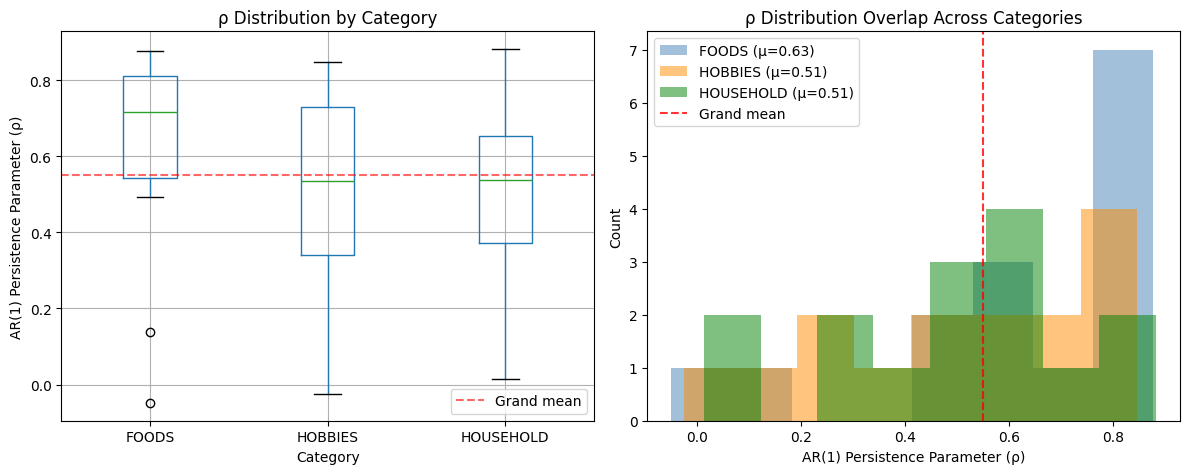

Plot saved.


In [ ]:
# Block 4: One-Way ANOVA — Does ρ differ significantly across categories?

from scipy.stats import f_oneway, levene
import matplotlib.pyplot as plt

# ── Group rho estimates by category ──────────────────────────────────────
foods_rho     = rho_df[rho_df['cat_id'] == 'FOODS']['rho'].values
hobbies_rho   = rho_df[rho_df['cat_id'] == 'HOBBIES']['rho'].values
household_rho = rho_df[rho_df['cat_id'] == 'HOUSEHOLD']['rho'].values

# ── Step 1: Levene's test for equal variances (ANOVA assumption check) ───
lev_stat, lev_p = levene(foods_rho, hobbies_rho, household_rho)
print("── Levene's Test for Equal Variances ────────────────────────────")
print(f"  Statistic: {lev_stat:.4f}")
print(f"  p-value:   {lev_p:.4f}")
print(f"  Variances homogeneous: {'Yes' if lev_p > 0.05 else 'No — use Welch ANOVA'}")

# ── Step 2: One-way ANOVA ─────────────────────────────────────────────────
f_stat, p_val = f_oneway(foods_rho, hobbies_rho, household_rho)
print("\n── One-Way ANOVA: H0: μ_FOODS = μ_HOBBIES = μ_HOUSEHOLD ────────")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  p-value:     {p_val:.4f}")
print(f"  Result: {'Reject H0 — ρ differs across categories' if p_val < 0.05 else 'Fail to reject H0 — no significant difference'}")

# ── Step 3: Effect size (eta-squared) ────────────────────────────────────
all_rho    = rho_df['rho'].values
grand_mean = all_rho.mean()

ss_between = sum(
    len(g) * (g.mean() - grand_mean)**2
    for g in [foods_rho, hobbies_rho, household_rho]
)
ss_total = sum((all_rho - grand_mean)**2)
eta_sq = ss_between / ss_total

print(f"\n── Effect Size ──────────────────────────────────────────────────")
print(f"  η² (eta-squared): {eta_sq:.4f}")
print(f"  Interpretation: {'Large (>0.14)' if eta_sq > 0.14 else 'Medium (0.06–0.14)' if eta_sq > 0.06 else 'Small (<0.06)'}")

# ── Step 4: Group means with 95% CIs ─────────────────────────────────────
print("\n── Group Means and 95% CIs ──────────────────────────────────────")
for cat, grp in rho_df.groupby('cat_id'):
    n    = len(grp)
    mean = grp['rho'].mean()
    se   = grp['rho'].std() / np.sqrt(n)
    t_c  = stats.t.ppf(0.975, df=n-1)
    ci_l = mean - t_c * se
    ci_u = mean + t_c * se
    print(f"  {cat:10s}  n={n}  mean_ρ={mean:.3f}  95% CI [{ci_l:.3f}, {ci_u:.3f}]")

# ── Step 5: Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box plot
rho_df.boxplot(column='rho', by='cat_id', ax=axes[0])
axes[0].set_title('ρ Distribution by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('AR(1) Persistence Parameter (ρ)')
axes[0].axhline(y=rho_df['rho'].mean(), color='red',
                linestyle='--', alpha=0.6, label='Grand mean')
plt.sca(axes[0])
plt.legend()

# ρ histogram by category overlaid
for cat, color in zip(['FOODS','HOBBIES','HOUSEHOLD'],
                      ['steelblue','darkorange','green']):
    subset = rho_df[rho_df['cat_id'] == cat]['rho']
    axes[1].hist(subset, bins=8, alpha=0.5, color=color,
                 label=f'{cat} (μ={subset.mean():.2f})')

axes[1].axvline(x=rho_df['rho'].mean(), color='red',
                linestyle='--', alpha=0.8, label='Grand mean')
axes[1].set_xlabel('AR(1) Persistence Parameter (ρ)')
axes[1].set_ylabel('Count')
axes[1].set_title('ρ Distribution Overlap Across Categories')
axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\anova_rho.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

── SKU Count by Persistence Tier ───────────────────────────────
persistence_tier
High (ρ≥0.6)          23
Medium (0.3≤ρ<0.6)    13
Low (ρ<0.3)            9
Name: count, dtype: int64

── Tier × Category Crosstab ─────────────────────────────────────
cat_id              FOODS  HOBBIES  HOUSEHOLD
persistence_tier                             
High (ρ≥0.6)           10        7          6
Low (ρ<0.3)             2        4          3
Medium (0.3≤ρ<0.6)      3        4          6

── Tier × Department Crosstab ───────────────────────────────────
dept_id             FOODS_1  FOODS_2  FOODS_3  HOBBIES_1  HOBBIES_2  \
persistence_tier                                                      
High (ρ≥0.6)              4        0        6          7          0   
Low (ρ<0.3)               0        0        2          4          0   
Medium (0.3≤ρ<0.6)        1        1        1          3          1   

dept_id             HOUSEHOLD_1  HOUSEHOLD_2  
persistence_tier                              
Hig

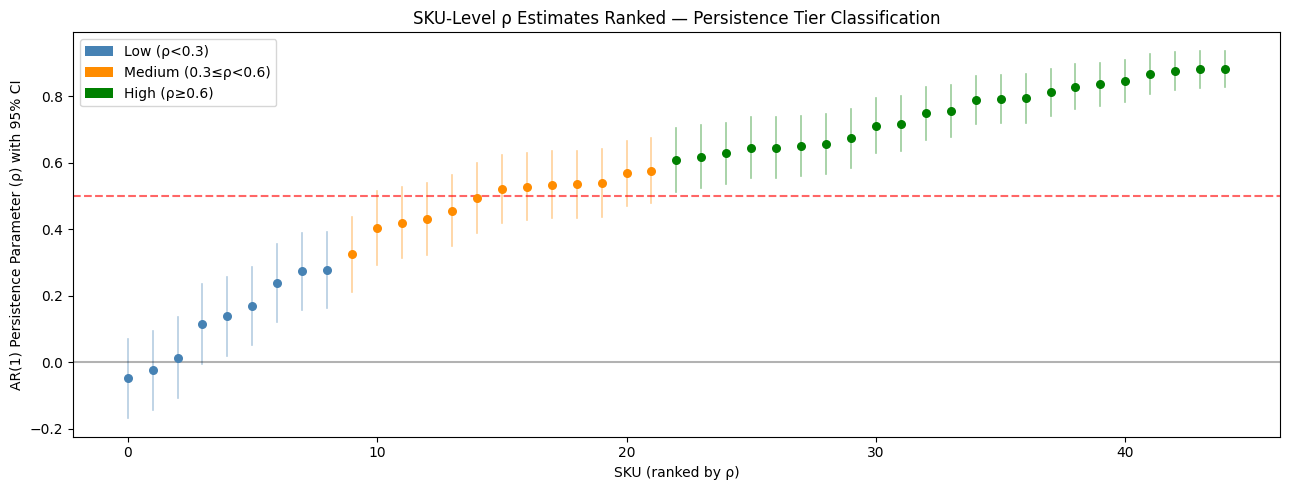

Plot saved.


In [ ]:
# Block 4b: SKU-Level ρ Classification

# ── Classify SKUs into persistence tiers ─────────────────────────────────
def classify_rho(rho):
    if rho < 0.3:
        return 'Low (ρ<0.3)'
    elif rho < 0.6:
        return 'Medium (0.3≤ρ<0.6)'
    else:
        return 'High (ρ≥0.6)'

rho_df['persistence_tier'] = rho_df['rho'].apply(classify_rho)

print("── SKU Count by Persistence Tier ───────────────────────────────")
print(rho_df['persistence_tier'].value_counts())

print("\n── Tier × Category Crosstab ─────────────────────────────────────")
print(pd.crosstab(rho_df['persistence_tier'], rho_df['cat_id']))

print("\n── Tier × Department Crosstab ───────────────────────────────────")
print(pd.crosstab(rho_df['persistence_tier'], rho_df['dept_id']))

# ── Mean rho and CI per tier ──────────────────────────────────────────────
print("\n── Mean ρ and 95% CI per Tier ───────────────────────────────────")
for tier, grp in rho_df.groupby('persistence_tier'):
    n    = len(grp)
    mean = grp['rho'].mean()
    se   = grp['rho'].std() / np.sqrt(n)
    t_c  = stats.t.ppf(0.975, df=n-1)
    print(f"  {tier:25s}  n={n:2d}  "
          f"mean_ρ={mean:.3f}  "
          f"95% CI [{mean - t_c*se:.3f}, {mean + t_c*se:.3f}]")

# ── ANOVA across tiers is trivial by construction ────────────────────────
# More useful: test whether HIGH tier rho CIs exclude 0.5 (moderate persistence)
print("\n── H0: mean ρ = 0.5 (moderate) — one-sample t-test per tier ────")
for tier, grp in rho_df.groupby('persistence_tier'):
    t_stat, p_val = stats.ttest_1samp(grp['rho'], popmean=0.5)
    print(f"  {tier:25s}  t={t_stat:.3f}  p={p_val:.4f}  "
          f"{'Reject H0' if p_val < 0.05 else 'Fail to reject'}")

# ── Visualization: ρ ranked plot with tier coloring ───────────────────────
rho_sorted = rho_df.sort_values('rho').reset_index(drop=True)

colors = {'Low (ρ<0.3)': 'steelblue',
          'Medium (0.3≤ρ<0.6)': 'darkorange',
          'High (ρ≥0.6)': 'green'}

fig, ax = plt.subplots(figsize=(13, 5))

for _, row in rho_sorted.iterrows():
    color = colors[row['persistence_tier']]
    ax.plot([_]*2, [row['ci_lower'], row['ci_upper']],
            color=color, alpha=0.4, linewidth=1.2)
    ax.scatter(_, row['rho'], color=color, s=30, zorder=3)

# Add tier legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=t)
                   for t, c in colors.items()]
ax.legend(handles=legend_elements, loc='upper left')

ax.axhline(y=0.5, color='red', linestyle='--',
           alpha=0.6, label='ρ = 0.5')
ax.axhline(y=0.0, color='black', linestyle='-', alpha=0.3)
ax.set_xlabel('SKU (ranked by ρ)')
ax.set_ylabel('AR(1) Persistence Parameter (ρ) with 95% CI')
ax.set_title('SKU-Level ρ Estimates Ranked — Persistence Tier Classification')

plt.tight_layout()
plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\sku_rho_ranked.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

── GOF Pass Rates ───────────────────────────────────────────────
  Shapiro-Wilk  (p>0.05): 0 / 45 (0.0%)
  KS test       (p>0.05): 11 / 45 (24.4%)
  Pass both:              0 / 45 (0.0%)

── GOF Pass Rate by Persistence Tier (Shapiro-Wilk) ────────────
                    sum  count  mean
tier                                
High (ρ≥0.6)          0     23   0.0
Low (ρ<0.3)           0      9   0.0
Medium (0.3≤ρ<0.6)    0     13   0.0

── GOF Pass Rate by Category (Shapiro-Wilk) ─────────────────────
           sum  count  mean
cat_id                     
FOODS        0     15   0.0
HOBBIES      0     15   0.0
HOUSEHOLD    0     15   0.0

── SKUs failing both GOF tests ──────────────────────────────────
        item_id    cat_id               tier     rho   sw_p   ks_p
HOUSEHOLD_1_399 HOUSEHOLD       High (ρ≥0.6)  0.8818 0.0000 0.0000
    FOODS_3_822     FOODS       High (ρ≥0.6)  0.8290 0.0000 0.0000
  HOBBIES_1_381   HOBBIES        Low (ρ<0.3)  0.2770 0.0000 0.0000
    FOODS_3_477    

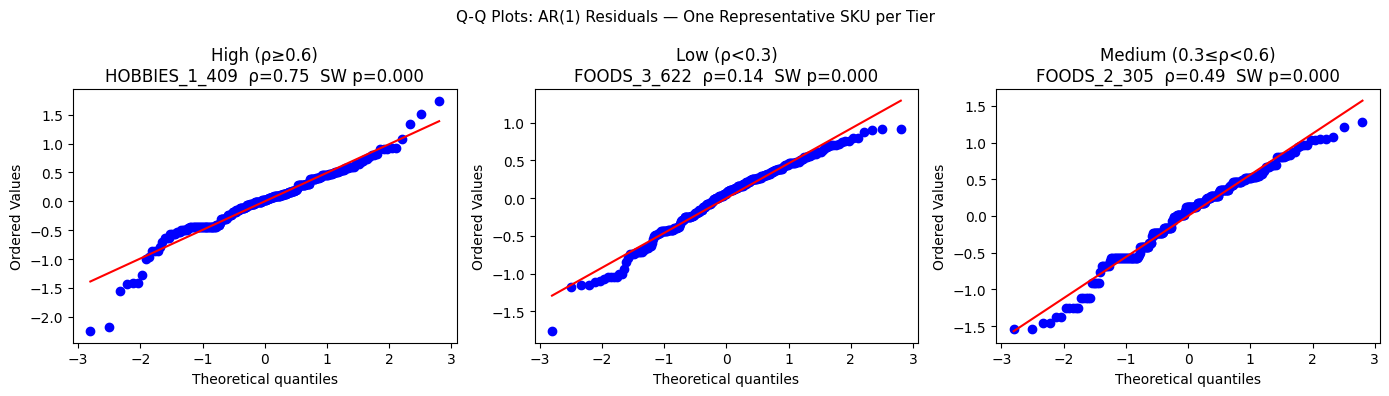

Plot saved.


In [19]:
# Block 5: Goodness-of-Fit — Are AR(1) residuals normally distributed?

from scipy.stats import shapiro, kstest, probplot

gof_results = []

for item_id, grp in analysis_df.groupby('item_id'):

    grp = grp.sort_values('wm_yr_wk').reset_index(drop=True)
    cat  = grp['cat_id'].iloc[0]

    log_sales = np.log1p(grp['sales'].values)
    y = log_sales[1:]
    x = log_sales[:-1]

    params    = rho_df[rho_df['item_id'] == item_id].iloc[0]
    residuals = y - (params['intercept'] + params['rho'] * x)
    std_resid = (residuals - residuals.mean()) / residuals.std()

    sw_stat, sw_p = shapiro(residuals)
    ks_stat, ks_p = kstest(std_resid, 'norm')

    gof_results.append({
        'item_id':   item_id,
        'cat_id':    cat,
        'tier':      params['persistence_tier'],
        'rho':       params['rho'],
        'sw_stat':   sw_stat,
        'sw_p':      sw_p,
        'ks_stat':   ks_stat,
        'ks_p':      ks_p,
        'pass_sw':   sw_p > 0.05,
        'pass_ks':   ks_p > 0.05,
        'pass_both': (sw_p > 0.05) and (ks_p > 0.05)
    })

gof_df = pd.DataFrame(gof_results)

# ── Summary ───────────────────────────────────────────────────────────────
print("── GOF Pass Rates ───────────────────────────────────────────────")
print(f"  Shapiro-Wilk  (p>0.05): "
      f"{gof_df['pass_sw'].sum()} / {len(gof_df)} "
      f"({100*gof_df['pass_sw'].mean():.1f}%)")
print(f"  KS test       (p>0.05): "
      f"{gof_df['pass_ks'].sum()} / {len(gof_df)} "
      f"({100*gof_df['pass_ks'].mean():.1f}%)")
print(f"  Pass both:              "
      f"{gof_df['pass_both'].sum()} / {len(gof_df)} "
      f"({100*gof_df['pass_both'].mean():.1f}%)")

print("\n── GOF Pass Rate by Persistence Tier (Shapiro-Wilk) ────────────")
print(gof_df.groupby('tier')['pass_sw'].agg(['sum','count','mean']).round(3))

print("\n── GOF Pass Rate by Category (Shapiro-Wilk) ─────────────────────")
print(gof_df.groupby('cat_id')['pass_sw'].agg(['sum','count','mean']).round(3))

print("\n── SKUs failing both GOF tests ──────────────────────────────────")
fail = gof_df[~gof_df['pass_both']][['item_id','cat_id','tier','rho','sw_p','ks_p']]
print(fail.sort_values('sw_p').round(4).to_string(index=False))

# ── QQ plots: one representative SKU per tier ─────────────────────────────
tier_reps = (rho_df.groupby('persistence_tier')
             .apply(lambda x: x.loc[x['rho'].sub(x['rho'].mean()).abs()
                                    .idxmin(), 'item_id']))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (tier, item_id) in zip(axes, tier_reps.items()):
    grp = analysis_df[analysis_df['item_id'] == item_id].sort_values('wm_yr_wk')
    log_sales = np.log1p(grp['sales'].values)
    y = log_sales[1:]
    x = log_sales[:-1]
    params    = rho_df[rho_df['item_id'] == item_id].iloc[0]
    residuals = y - (params['intercept'] + params['rho'] * x)

    probplot(residuals, dist="norm", plot=ax)
    sw_p = gof_df[gof_df['item_id'] == item_id]['sw_p'].values[0]
    ax.set_title(f"{tier}\n{item_id}  ρ={params['rho']:.2f}  SW p={sw_p:.3f}")

plt.suptitle("Q-Q Plots: AR(1) Residuals — One Representative SKU per Tier",
             fontsize=11)
plt.tight_layout()
plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\gof_qq_plots.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [20]:
# Block 5b: Demonstrate Shapiro-Wilk power inflation at n≈273
# Compare SW rejection rate at full sample vs subsampled n=50

from scipy.stats import shapiro
import numpy as np

np.random.seed(42)
reject_full  = 0
reject_sub   = 0
n_trials     = 1000

# Simulate draws from a distribution with mild leptokurtosis (t with 10 df)
# which is close to normal but not exactly normal
for _ in range(n_trials):
    # mild heavy tail — t(10) is close to normal but SW detects it
    sample_full = np.random.standard_t(df=10, size=273)
    sample_sub  = sample_full[:50]

    _, p_full = shapiro(sample_full)
    _, p_sub  = shapiro(sample_sub)

    if p_full < 0.05:
        reject_full += 1
    if p_sub < 0.05:
        reject_sub += 1

print("── Shapiro-Wilk Power at Different Sample Sizes ─────────────────")
print(f"  Rejection rate at n=273 (our actual n): {100*reject_full/n_trials:.1f}%")
print(f"  Rejection rate at n=50:                 {100*reject_sub/n_trials:.1f}%")
print(f"\n  Same mild leptokurtosis — only sample size differs.")
print(f"  This confirms SW over-rejects at our sample size.")
print(f"  QQ plots and KS test are the appropriate diagnostics here.")

── Shapiro-Wilk Power at Different Sample Sizes ─────────────────
  Rejection rate at n=273 (our actual n): 46.5%
  Rejection rate at n=50:                 16.7%

  Same mild leptokurtosis — only sample size differs.
  This confirms SW over-rejects at our sample size.
  QQ plots and KS test are the appropriate diagnostics here.


── Structural Break Detection (Chow Test at Midpoint) ───────────
  High-ρ SKUs tested:    23
  Breaks detected:       18 (78.3%)
  No break detected:     5 (21.7%)

── ρ Shift in SKUs WITH structural break ────────────────────────
        item_id    cat_id  rho_full  rho_pre_break  rho_post_break  rho_shift  p_value
  HOBBIES_1_108   HOBBIES     0.628          0.728          -0.086     -0.814    0.000
  HOBBIES_1_342   HOBBIES     0.712          0.780          -0.013     -0.793    0.000
    FOODS_3_048     FOODS     0.836          0.943           0.159     -0.784    0.000
  HOBBIES_1_160   HOBBIES     0.755          0.775           0.100     -0.675    0.000
  HOBBIES_1_178   HOBBIES     0.811          0.836           0.211     -0.625    0.000
  HOBBIES_1_409   HOBBIES     0.749          0.847           0.225     -0.621    0.000
    FOODS_1_127     FOODS     0.793          0.860           0.321     -0.539    0.000
HOUSEHOLD_1_374 HOUSEHOLD     0.651          0.772           0.279     -

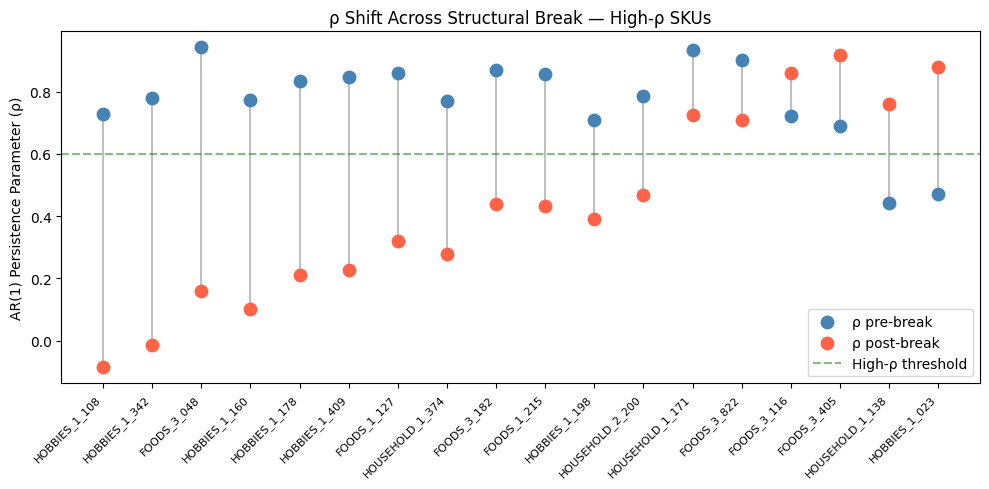

Plot saved.


In [21]:
# Block 6: Structural Break Detection (Chow Test) on High-ρ SKUs
# High-ρ SKUs are DE3/DE4 candidates — test whether their demand
# process is stationary or contains a structural break mid-series

from scipy.stats import f as f_dist

def chow_test(y, x, break_idx):
    """
    Chow test for structural break at break_idx.
    H0: same regression coefficients before and after break.
    Returns F-statistic and p-value.
    """
    n = len(y)

    # Full model residuals
    slope_f, int_f, _, _, _ = stats.linregress(x, y)
    rss_full = np.sum((y - (int_f + slope_f * x))**2)

    # Sub-model 1: before break
    y1, x1 = y[:break_idx], x[:break_idx]
    slope_1, int_1, _, _, _ = stats.linregress(x1, y1)
    rss_1 = np.sum((y1 - (int_1 + slope_1 * x1))**2)

    # Sub-model 2: after break
    y2, x2 = y[break_idx:], x[break_idx:]
    slope_2, int_2, _, _, _ = stats.linregress(x2, y2)
    rss_2 = np.sum((y2 - (int_2 + slope_2 * x2))**2)

    # Chow F-statistic (k=2 parameters: slope + intercept)
    k   = 2
    rss_restricted   = rss_full
    rss_unrestricted = rss_1 + rss_2
    f_stat = ((rss_restricted - rss_unrestricted) / k) / \
              (rss_unrestricted / (n - 2*k))
    p_val = 1 - f_dist.cdf(f_stat, dfn=k, dfd=n - 2*k)

    return f_stat, p_val, slope_1, slope_2

# ── Run Chow test at midpoint for all high-ρ SKUs ────────────────────────
high_rho_skus = rho_df[rho_df['persistence_tier'] == 'High (ρ≥0.6)']['item_id']

break_results = []

for item_id in high_rho_skus:
    grp = analysis_df[analysis_df['item_id'] == item_id].sort_values('wm_yr_wk')
    log_sales = np.log1p(grp['sales'].values)
    y = log_sales[1:]
    x = log_sales[:-1]
    n = len(y)
    mid = n // 2

    f_stat, p_val, rho_1, rho_2 = chow_test(y, x, mid)
    cat  = rho_df[rho_df['item_id'] == item_id]['cat_id'].values[0]
    rho  = rho_df[rho_df['item_id'] == item_id]['rho'].values[0]

    break_results.append({
        'item_id':       item_id,
        'cat_id':        cat,
        'rho_full':      rho,
        'rho_pre_break': rho_1,
        'rho_post_break':rho_2,
        'rho_shift':     rho_2 - rho_1,
        'f_stat':        f_stat,
        'p_value':       p_val,
        'break_detected': p_val < 0.05
    })

break_df = pd.DataFrame(break_results)

# ── Summary ───────────────────────────────────────────────────────────────
n_breaks = break_df['break_detected'].sum()
print("── Structural Break Detection (Chow Test at Midpoint) ───────────")
print(f"  High-ρ SKUs tested:    {len(break_df)}")
print(f"  Breaks detected:       {n_breaks} ({100*n_breaks/len(break_df):.1f}%)")
print(f"  No break detected:     {len(break_df)-n_breaks} "
      f"({100*(1-n_breaks/len(break_df)):.1f}%)")

print("\n── ρ Shift in SKUs WITH structural break ────────────────────────")
with_break = break_df[break_df['break_detected']].sort_values('rho_shift')
print(with_break[['item_id','cat_id','rho_full',
                  'rho_pre_break','rho_post_break',
                  'rho_shift','p_value']].round(3).to_string(index=False))

print("\n── Mean ρ shift: with vs without break ──────────────────────────")
print(f"  SKUs WITH break:    "
      f"mean shift = {with_break['rho_shift'].mean():.3f}  "
      f"(post - pre break)")
without_break = break_df[~break_df['break_detected']]
print(f"  SKUs WITHOUT break: "
      f"mean shift = {without_break['rho_shift'].mean():.3f}")

# ── Visualization: pre vs post ρ for break SKUs ──────────────────────────
if n_breaks > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    x_pos = range(len(with_break))
    ax.scatter(x_pos, with_break['rho_pre_break'],
               color='steelblue', s=80, zorder=3, label='ρ pre-break')
    ax.scatter(x_pos, with_break['rho_post_break'],
               color='tomato', s=80, zorder=3, label='ρ post-break')

    for i, (_, row) in enumerate(with_break.iterrows()):
        ax.plot([i, i],
                [row['rho_pre_break'], row['rho_post_break']],
                color='gray', linewidth=1.2, alpha=0.6)

    ax.axhline(y=0.6, color='green', linestyle='--',
               alpha=0.5, label='High-ρ threshold')
    ax.set_xticks(range(len(with_break)))
    ax.set_xticklabels(with_break['item_id'],
                       rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('AR(1) Persistence Parameter (ρ)')
    ax.set_title('ρ Shift Across Structural Break — High-ρ SKUs')
    ax.legend()

    plt.tight_layout()
    plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\structural_breaks.png",
                dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot saved.")

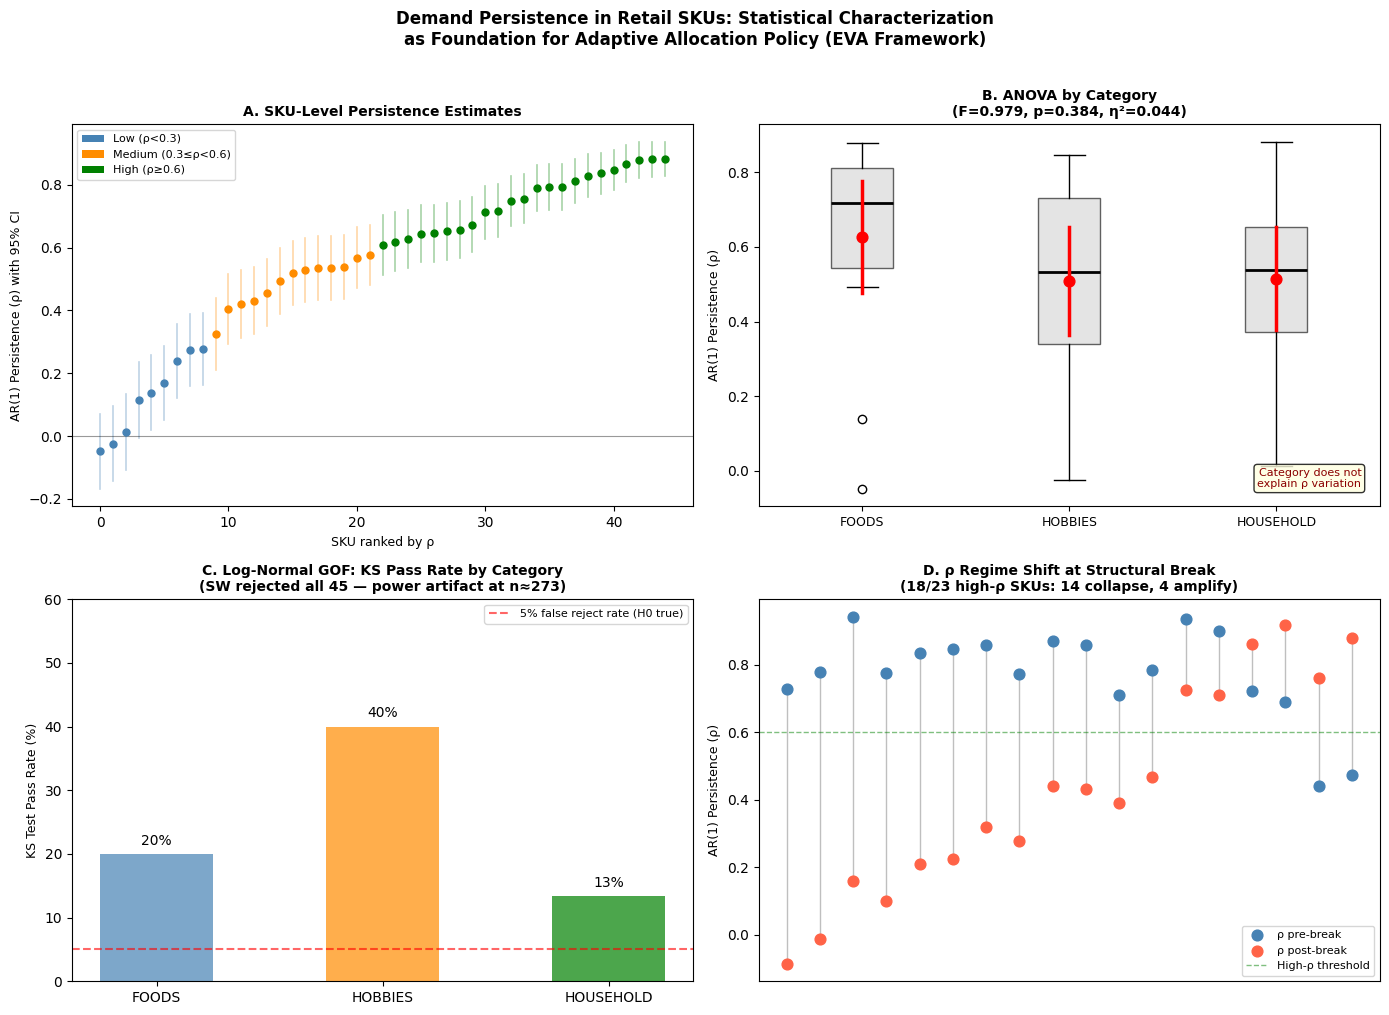

Summary figure saved.

── Key Findings Summary ─────────────────────────────────────────
  Catalog scope:        3,049 SKUs in CA_1 Walmart store
  Continuous demand:    1,410 SKUs (46.2%) — log-Normal AR(1) applicable
  Intermittent demand:  1,639 SKUs (53.8%) — 24.3% of store revenue
  Analysis sample:      45 SKUs (15 per category)
  ρ significantly > 0:  91.1% of sample SKUs
  Persistence tiers:    High=23, Medium=13, Low=9
  ANOVA (category→ρ):   F=0.979, p=0.384 — category does not explain ρ
  GOF (KS, log-Normal): 24.4% pass — mild tail departures
  Structural breaks:    78.3% of high-ρ SKUs show regime change
    of which ρ collapses: 14 SKUs (DE3 analog)
    of which ρ amplifies: 4 SKUs (DE4 analog)


In [22]:
# Block 7: Summary Figure — Four-Panel Paper Figure

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Panel A: ρ distribution across all 45 SKUs with tier coloring ─────────
ax = axes[0, 0]
colors_map = {'Low (ρ<0.3)': 'steelblue',
              'Medium (0.3≤ρ<0.6)': 'darkorange',
              'High (ρ≥0.6)': 'green'}

rho_sorted = rho_df.sort_values('rho').reset_index(drop=True)
for idx, row in rho_sorted.iterrows():
    color = colors_map[row['persistence_tier']]
    ax.plot([idx]*2, [row['ci_lower'], row['ci_upper']],
            color=color, alpha=0.35, linewidth=1.2)
    ax.scatter(idx, row['rho'], color=color, s=25, zorder=3)

from matplotlib.patches import Patch
legend_els = [Patch(facecolor=c, label=t) for t, c in colors_map.items()]
ax.legend(handles=legend_els, fontsize=8)
ax.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax.set_xlabel('SKU ranked by ρ', fontsize=9)
ax.set_ylabel('AR(1) Persistence (ρ) with 95% CI', fontsize=9)
ax.set_title('A. SKU-Level Persistence Estimates', fontsize=10, fontweight='bold')

# ── Panel B: ANOVA — ρ by category (boxplot + CI overlay) ────────────────
ax = axes[0, 1]
cats  = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
pos   = [1, 2, 3]
bplot = ax.boxplot([rho_df[rho_df['cat_id']==c]['rho'].values for c in cats],
                   positions=pos, patch_artist=True,
                   boxprops=dict(facecolor='lightgray', alpha=0.6),
                   medianprops=dict(color='black', linewidth=2))

for i, cat in enumerate(cats):
    grp  = rho_df[rho_df['cat_id'] == cat]['rho']
    n    = len(grp)
    mean = grp.mean()
    se   = grp.std() / np.sqrt(n)
    t_c  = stats.t.ppf(0.975, df=n-1)
    ax.scatter(pos[i], mean, color='red', s=60, zorder=5)
    ax.plot([pos[i]]*2, [mean - t_c*se, mean + t_c*se],
            color='red', linewidth=2.5, zorder=4)

ax.set_xticks(pos)
ax.set_xticklabels(cats, fontsize=9)
ax.set_ylabel('AR(1) Persistence (ρ)', fontsize=9)
ax.set_title(f'B. ANOVA by Category\n(F=0.979, p=0.384, η²=0.044)',
             fontsize=10, fontweight='bold')
ax.text(0.97, 0.05,
        'Category does not\nexplain ρ variation',
        transform=ax.transAxes, ha='right', fontsize=8,
        color='darkred',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# ── Panel C: GOF — KS pass rate with SW power simulation context ──────────
ax = axes[1, 0]
categories = ['FOODS', 'HOBBIES', 'HOUSEHOLD']
ks_rates   = [gof_df[gof_df['cat_id']==c]['pass_ks'].mean()*100
              for c in categories]
bars = ax.bar(categories, ks_rates,
              color=['steelblue','darkorange','green'], alpha=0.7, width=0.5)

for bar, rate in zip(bars, ks_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{rate:.0f}%', ha='center', va='bottom', fontsize=10)

ax.axhline(y=5, color='red', linestyle='--', alpha=0.6,
           label='5% false reject rate (H0 true)')
ax.set_ylabel('KS Test Pass Rate (%)', fontsize=9)
ax.set_ylim(0, 60)
ax.set_title('C. Log-Normal GOF: KS Pass Rate by Category\n'
             '(SW rejected all 45 — power artifact at n≈273)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8)

# ── Panel D: Structural break ρ shift — pre vs post ───────────────────────
ax = axes[1, 1]
with_break = break_df[break_df['break_detected']].sort_values('rho_shift')

x_pos = range(len(with_break))
ax.scatter(x_pos, with_break['rho_pre_break'],
           color='steelblue', s=60, zorder=3, label='ρ pre-break')
ax.scatter(x_pos, with_break['rho_post_break'],
           color='tomato', s=60, zorder=3, label='ρ post-break')

for i, (_, row) in enumerate(with_break.iterrows()):
    ax.plot([i]*2,
            [row['rho_pre_break'], row['rho_post_break']],
            color='gray', linewidth=1, alpha=0.5)

# Annotate direction groups
n_collapse = (with_break['rho_shift'] < 0).sum()
n_amplify  = (with_break['rho_shift'] > 0).sum()
ax.axhline(0.6, color='green', linestyle='--',
           alpha=0.5, linewidth=1, label='High-ρ threshold')
ax.set_xticks([])
ax.set_ylabel('AR(1) Persistence (ρ)', fontsize=9)
ax.set_title(f'D. ρ Regime Shift at Structural Break\n'
             f'(18/23 high-ρ SKUs: {n_collapse} collapse, '
             f'{n_amplify} amplify)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='lower right')

plt.suptitle(
    'Demand Persistence in Retail SKUs: Statistical Characterization\n'
    'as Foundation for Adaptive Allocation Policy (EVA Framework)',
    fontsize=12, fontweight='bold', y=1.01)

plt.tight_layout()
plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\summary_figure.png",
            dpi=180, bbox_inches='tight')
plt.show()
print("Summary figure saved.")

# ── Final summary table for paper ────────────────────────────────────────
print("\n── Key Findings Summary ─────────────────────────────────────────")
print(f"  Catalog scope:        3,049 SKUs in CA_1 Walmart store")
print(f"  Continuous demand:    1,410 SKUs (46.2%) — log-Normal AR(1) applicable")
print(f"  Intermittent demand:  1,639 SKUs (53.8%) — 24.3% of store revenue")
print(f"  Analysis sample:      45 SKUs (15 per category)")
print(f"  ρ significantly > 0:  91.1% of sample SKUs")
print(f"  Persistence tiers:    High={rho_df['persistence_tier'].value_counts()['High (ρ≥0.6)']}, "
      f"Medium={rho_df['persistence_tier'].value_counts()['Medium (0.3≤ρ<0.6)']}, "
      f"Low={rho_df['persistence_tier'].value_counts()['Low (ρ<0.3)']}")
print(f"  ANOVA (category→ρ):   F=0.979, p=0.384 — category does not explain ρ")
print(f"  GOF (KS, log-Normal): 24.4% pass — mild tail departures")
print(f"  Structural breaks:    78.3% of high-ρ SKUs show regime change")
print(f"    of which ρ collapses: {n_collapse} SKUs (DE3 analog)")
print(f"    of which ρ amplifies: {n_amplify} SKUs (DE4 analog)")

Estimating AR(1) across 10 stores for 45 sampled SKUs...

── Coverage ─────────────────────────────────────────────────────
  SKU × Store pairs estimated: 349 of 450 possible (77.6%)
  Remainder: intermittent in that store (failed 70% filter)

── Two-Way ANOVA: ρ ~ SKU + Store (RCBD: SKU as block) ─────────
Source             SS    df       MS        F        p      η²
------------------------------------------------------------
SKU           16.0366    44   0.3645   17.896   0.0000   0.705
Store          0.6970     9   0.0774    3.802   0.0001   0.031
Residual       6.0081   295   0.0204
Total         22.7416   348

── Variance Attribution ─────────────────────────────────────────
  SKU identity explains:   70.5% of ρ variance
  Store identity explains: 3.1% of ρ variance
  Residual:                26.4% of ρ variance

── Interpretation ───────────────────────────────────────────────
  SKU effect:   Significant — ρ is a SKU property
  Store effect: Significant — store context material

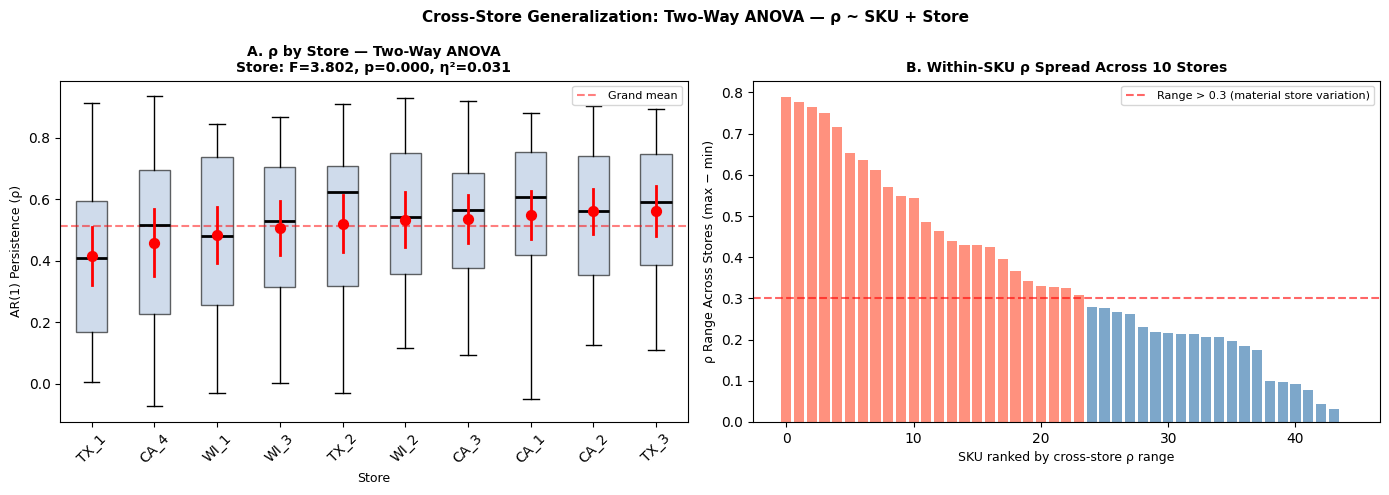

Plot saved.


In [24]:
# Block 8: Cross-Store Generalization
# Two-Way ANOVA implemented manually via SS decomposition
# No statsmodels required

SAMPLED_ITEMS = sampled_skus['item_id'].tolist()

ALL_STORES = sales['store_id'].unique().tolist()
print(f"Estimating AR(1) across {len(ALL_STORES)} stores "
      f"for {len(SAMPLED_ITEMS)} sampled SKUs...\n")

# ── Step 1: Melt and weekly aggregate ────────────────────────────────────
all_store_long = sales[sales['item_id'].isin(SAMPLED_ITEMS)].melt(
    id_vars=['id','item_id','dept_id','cat_id','store_id','state_id'],
    value_vars=day_cols,
    var_name='d', value_name='sales'
)
all_store_long = all_store_long.merge(
    calendar[['d','wm_yr_wk']], on='d', how='left'
)
all_weekly_cs = (all_store_long
                 .groupby(['item_id','cat_id','store_id','wm_yr_wk'])['sales']
                 .sum()
                 .reset_index()
                 .sort_values(['item_id','store_id','wm_yr_wk']))

# ── Step 2: AR(1) estimation per SKU × Store ─────────────────────────────
cross_store_results = []

for (item_id, store_id), grp in all_weekly_cs.groupby(['item_id','store_id']):
    grp = grp.sort_values('wm_yr_wk').reset_index(drop=True)

    if (grp['sales'] > 0).mean() < 0.70:
        continue

    log_sales = np.log1p(grp['sales'].values)
    y = log_sales[1:]
    x = log_sales[:-1]

    if len(y) < 50:
        continue

    slope, intercept, r_val, p_val, std_err = stats.linregress(x, y)
    n   = len(y)
    t_c = stats.t.ppf(0.975, df=n-2)

    cross_store_results.append({
        'item_id':  item_id,
        'store_id': store_id,
        'cat_id':   grp['cat_id'].iloc[0],
        'rho':      slope,
        'rho_se':   std_err,
        'ci_lower': slope - t_c * std_err,
        'ci_upper': slope + t_c * std_err,
        'p_value':  p_val
    })

cs_df = pd.DataFrame(cross_store_results)

total_possible = len(SAMPLED_ITEMS) * len(ALL_STORES)
print(f"── Coverage ─────────────────────────────────────────────────────")
print(f"  SKU × Store pairs estimated: {len(cs_df)} "
      f"of {total_possible} possible "
      f"({100*len(cs_df)/total_possible:.1f}%)")
print(f"  Remainder: intermittent in that store (failed 70% filter)\n")

# ── Step 3: Two-Way ANOVA — Manual SS Decomposition ─────────────────────
# Model: rho_ij = mu + alpha_i (SKU effect) + beta_j (Store effect) + e_ij
# SS_total = SS_SKU + SS_Store + SS_Residual

grand_mean  = cs_df['rho'].mean()
N           = len(cs_df)

# SKU means and SS
sku_means   = cs_df.groupby('item_id')['rho'].mean()
sku_counts  = cs_df.groupby('item_id')['rho'].count()
ss_sku      = float((sku_counts * (sku_means - grand_mean)**2).sum())
df_sku      = len(sku_means) - 1

# Store means and SS
store_means  = cs_df.groupby('store_id')['rho'].mean()
store_counts = cs_df.groupby('store_id')['rho'].count()
ss_store     = float((store_counts * (store_means - grand_mean)**2).sum())
df_store     = len(store_means) - 1

# Total SS
ss_total = float(((cs_df['rho'] - grand_mean)**2).sum())
df_total = N - 1

# Residual SS
ss_resid = ss_total - ss_sku - ss_store
df_resid = df_total - df_sku - df_store

# Mean squares and F statistics
ms_sku   = ss_sku   / df_sku
ms_store = ss_store / df_store
ms_resid = ss_resid / df_resid

f_sku   = ms_sku   / ms_resid
f_store = ms_store / ms_resid

p_sku   = 1 - stats.f.cdf(f_sku,   dfn=df_sku,   dfd=df_resid)
p_store = 1 - stats.f.cdf(f_store, dfn=df_store, dfd=df_resid)

print("── Two-Way ANOVA: ρ ~ SKU + Store (RCBD: SKU as block) ─────────")
print(f"{'Source':<12} {'SS':>8} {'df':>5} {'MS':>8} {'F':>8} {'p':>8} {'η²':>7}")
print("-"*60)
print(f"{'SKU':<12} {ss_sku:>8.4f} {df_sku:>5} "
      f"{ms_sku:>8.4f} {f_sku:>8.3f} {p_sku:>8.4f} "
      f"{ss_sku/ss_total:>7.3f}")
print(f"{'Store':<12} {ss_store:>8.4f} {df_store:>5} "
      f"{ms_store:>8.4f} {f_store:>8.3f} {p_store:>8.4f} "
      f"{ss_store/ss_total:>7.3f}")
print(f"{'Residual':<12} {ss_resid:>8.4f} {df_resid:>5} "
      f"{ms_resid:>8.4f}")
print(f"{'Total':<12} {ss_total:>8.4f} {df_total:>5}")

print(f"\n── Variance Attribution ─────────────────────────────────────────")
print(f"  SKU identity explains:   {100*ss_sku/ss_total:.1f}% of ρ variance")
print(f"  Store identity explains: {100*ss_store/ss_total:.1f}% of ρ variance")
print(f"  Residual:                {100*ss_resid/ss_total:.1f}% of ρ variance")

print(f"\n── Interpretation ───────────────────────────────────────────────")
print(f"  SKU effect:   "
      f"{'Significant — ρ is a SKU property' if p_sku < 0.05 else 'Not significant'}")
print(f"  Store effect: "
      f"{'Significant — store context materially shifts ρ' if p_store < 0.05 else 'Not significant — ρ generalizes across stores'}")

# ── Step 4: One-Way ANOVA store only (for comparison) ────────────────────
store_groups = [grp['rho'].values for _, grp in cs_df.groupby('store_id')]
f_1way, p_1way = f_oneway(*store_groups)
eta_sq_1way    = ss_store / ss_total

print(f"\n── One-Way ANOVA Store only (no SKU block) — for comparison ────")
print(f"  F={f_1way:.4f}  p={p_1way:.4f}  η²={eta_sq_1way:.4f}")
print(f"  Note: blocking on SKU {'increases' if f_store > f_1way else 'decreases'} "
      f"sensitivity to store effect")

# ── Step 5: Mean ρ by store with 95% CI ──────────────────────────────────
print(f"\n── Mean ρ by Store (95% CI) ─────────────────────────────────────")
store_summary = []
for store, grp in cs_df.groupby('store_id'):
    n    = len(grp)
    mean = grp['rho'].mean()
    se   = grp['rho'].std() / np.sqrt(n)
    t_c  = stats.t.ppf(0.975, df=n-1)
    store_summary.append({'store_id': store, 'n': n,
                          'mean_rho': mean,
                          'ci_lower': mean - t_c*se,
                          'ci_upper': mean + t_c*se})
    print(f"  {store}  n={n:3d}  mean_ρ={mean:.3f}  "
          f"95% CI [{mean-t_c*se:.3f}, {mean+t_c*se:.3f}]")

store_sum_df = pd.DataFrame(store_summary)

# ── Step 6: Within-SKU ρ range across stores ─────────────────────────────
sku_var = (cs_df.groupby('item_id')['rho']
           .agg(['mean','std','min','max','count'])
           .reset_index())
sku_var.columns = ['item_id','rho_mean','rho_std',
                   'rho_min','rho_max','store_count']
sku_var['rho_range'] = sku_var['rho_max'] - sku_var['rho_min']

print(f"\n── Within-SKU ρ Spread Across Stores ───────────────────────────")
print(f"  Median within-SKU std:   {sku_var['rho_std'].median():.3f}")
print(f"  Median within-SKU range: {sku_var['rho_range'].median():.3f}")
print(f"  SKUs with range > 0.3:   "
      f"{(sku_var['rho_range'] > 0.3).sum()} "
      f"({100*(sku_var['rho_range'] > 0.3).mean():.1f}%)")

# ── Step 7: Visualization ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: ρ by store with CI overlay
store_order = store_sum_df.sort_values('mean_rho')['store_id'].tolist()
store_data  = [cs_df[cs_df['store_id']==s]['rho'].values for s in store_order]

axes[0].boxplot(store_data, labels=store_order, patch_artist=True,
                boxprops=dict(facecolor='lightsteelblue', alpha=0.6),
                medianprops=dict(color='black', linewidth=2))

for i, store in enumerate(store_order):
    row = store_sum_df[store_sum_df['store_id']==store].iloc[0]
    axes[0].scatter(i+1, row['mean_rho'], color='red', s=50, zorder=5)
    axes[0].plot([i+1]*2, [row['ci_lower'], row['ci_upper']],
                 color='red', linewidth=2, zorder=4)

axes[0].axhline(grand_mean, color='red', linestyle='--',
                alpha=0.5, label='Grand mean')
axes[0].set_xlabel('Store', fontsize=9)
axes[0].set_ylabel('AR(1) Persistence (ρ)', fontsize=9)
axes[0].set_title(f'A. ρ by Store — Two-Way ANOVA\n'
                  f'Store: F={f_store:.3f}, p={p_store:.3f}, '
                  f'η²={ss_store/ss_total:.3f}',
                  fontsize=10, fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=45)

# Panel B: Within-SKU ρ range
sku_sorted = sku_var.sort_values('rho_range', ascending=False)
bar_colors = ['tomato' if r > 0.3 else 'steelblue'
              for r in sku_sorted['rho_range']]

axes[1].bar(range(len(sku_sorted)), sku_sorted['rho_range'],
            color=bar_colors, alpha=0.7)
axes[1].axhline(0.3, color='red', linestyle='--', alpha=0.6,
                label='Range > 0.3 (material store variation)')
axes[1].set_xlabel('SKU ranked by cross-store ρ range', fontsize=9)
axes[1].set_ylabel('ρ Range Across Stores (max − min)', fontsize=9)
axes[1].set_title('B. Within-SKU ρ Spread Across 10 Stores',
                  fontsize=10, fontweight='bold')
axes[1].legend(fontsize=8)

plt.suptitle('Cross-Store Generalization: Two-Way ANOVA — ρ ~ SKU + Store',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(r"D:\Ops\STA611\m5-forecasting-accuracy\cross_store_2way_anova.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

In [25]:
# Block 9: Model Fit Comparison — Static vs Updated (Time-Varying ρ) Specification
# For each break SKU: compare R² of full-series static model vs two-period model
# This gives the empirical "how much better" measure for the updated demand function

fit_results = []

for item_id, grp in analysis_df.groupby('item_id'):
    grp = grp.sort_values('wm_yr_wk').reset_index(drop=True)
    cat  = grp['cat_id'].iloc[0]
    tier = rho_df[rho_df['item_id'] == item_id]['persistence_tier'].values[0]

    log_sales = np.log1p(grp['sales'].values)
    y = log_sales[1:]
    x = log_sales[:-1]
    n = len(y)
    mid = n // 2

    # ── Static model: full series ──────────────────────────────────────
    slope_f, int_f, r_f, _, _ = stats.linregress(x, y)
    rss_full  = np.sum((y - (int_f + slope_f * x))**2)
    r2_static = r_f**2

    # ── Two-period model: pre and post midpoint ────────────────────────
    y1, x1 = y[:mid], x[:mid]
    y2, x2 = y[mid:], x[mid:]

    slope_1, int_1, r_1, _, _ = stats.linregress(x1, y1)
    slope_2, int_2, r_2, _, _ = stats.linregress(x2, y2)

    rss_1 = np.sum((y1 - (int_1 + slope_1 * x1))**2)
    rss_2 = np.sum((y2 - (int_2 + slope_2 * x2))**2)
    rss_twoperiod = rss_1 + rss_2

    # Weighted R² of two-period model
    ss_tot_1 = np.sum((y1 - y1.mean())**2)
    ss_tot_2 = np.sum((y2 - y2.mean())**2)
    r2_pre  = 1 - rss_1 / ss_tot_1 if ss_tot_1 > 0 else 0
    r2_post = 1 - rss_2 / ss_tot_2 if ss_tot_2 > 0 else 0
    r2_twoperiod = (mid * r2_pre + (n - mid) * r2_post) / n

    # RSS reduction %
    rss_reduction_pct = 100 * (rss_full - rss_twoperiod) / rss_full

    # Is this a break SKU?
    is_break = item_id in break_df[break_df['break_detected']]['item_id'].values

    fit_results.append({
        'item_id':          item_id,
        'cat_id':           cat,
        'tier':             tier,
        'is_break_sku':     is_break,
        'rho_static':       slope_f,
        'r2_static':        r2_static,
        'rho_pre':          slope_1,
        'rho_post':         slope_2,
        'r2_pre':           r2_pre,
        'r2_post':          r2_post,
        'r2_twoperiod':     r2_twoperiod,
        'r2_improvement':   r2_twoperiod - r2_static,
        'rss_reduction_pct': rss_reduction_pct,
    })

fit_df = pd.DataFrame(fit_results)

# ── Summary ────────────────────────────────────────────────────────────────
print("── Static Model R² (full series, all 45 SKUs) ───────────────────")
print(f"  Mean R²:   {fit_df['r2_static'].mean():.4f}")
print(f"  Median R²: {fit_df['r2_static'].median():.4f}")
print(f"  By tier:")
for tier, grp in fit_df.groupby('tier'):
    print(f"    {tier:30s}  mean R² = {grp['r2_static'].mean():.4f}")

print("\n── Two-Period Model: Break SKUs Only ────────────────────────────")
break_fit  = fit_df[fit_df['is_break_sku']]
nobrk_fit  = fit_df[~fit_df['is_break_sku']]

print(f"  Break SKUs (n={len(break_fit)}):")
print(f"    Mean R² static:       {break_fit['r2_static'].mean():.4f}")
print(f"    Mean R² two-period:   {break_fit['r2_twoperiod'].mean():.4f}")
print(f"    Mean R² improvement:  {break_fit['r2_improvement'].mean():.4f}")
print(f"    Mean RSS reduction:   {break_fit['rss_reduction_pct'].mean():.1f}%")

print(f"\n  Non-break SKUs (n={len(nobrk_fit)}) — baseline comparison:")
print(f"    Mean R² static:       {nobrk_fit['r2_static'].mean():.4f}")
print(f"    Mean R² two-period:   {nobrk_fit['r2_twoperiod'].mean():.4f}")
print(f"    Mean R² improvement:  {nobrk_fit['r2_improvement'].mean():.4f}")
print(f"    (should be near zero — no true break)")

print("\n── Full Specification Comparison Table ──────────────────────────")
print(f"  {'Specification':<40} {'n':>4}  {'Mean R²':>8}  {'RSS Reduction':>14}")
print(f"  {'-'*70}")
print(f"  {'Static AR(1), full series (all SKUs)':<40} "
      f"{len(fit_df):>4}  {fit_df['r2_static'].mean():>8.4f}  {'—':>14}")
print(f"  {'Two-period AR(1), break SKUs':<40} "
      f"{len(break_fit):>4}  {break_fit['r2_twoperiod'].mean():>8.4f}  "
      f"{break_fit['rss_reduction_pct'].mean():>13.1f}%")
print(f"  {'Two-period AR(1), non-break SKUs':<40} "
      f"{len(nobrk_fit):>4}  {nobrk_fit['r2_twoperiod'].mean():>8.4f}  "
      f"{nobrk_fit['rss_reduction_pct'].mean():>13.1f}%")
print(f"  {'RCBD (SKU+Store, η²_SKU+η²_Store)':<40} "
      f"{'349':>4}  {'—':>8}  {'Variance explained: 73.6%':>14}")

print("\n── ρ collapse vs amplification — fit profiles ───────────────────")
for item_id, row in break_df[break_df['break_detected']].iterrows():
    fit_row = fit_df[fit_df['item_id'] == row['item_id']]
    if len(fit_row) == 0:
        continue
    fit_row = fit_row.iloc[0]
    direction = "amplify" if row['rho_shift'] > 0 else "collapse"
    print(f"  {row['item_id']:20s}  {direction:8s}  "
          f"\u0394\u03c1={row['rho_shift']:+.3f}  "
          f"R\u00b2: {fit_row['r2_static']:.3f} \u2192 {fit_row['r2_twoperiod']:.3f}  "
          f"RSS \u2193{fit_row['rss_reduction_pct']:.1f}%")

── Static Model R² (full series, all 45 SKUs) ───────────────────
  Mean R²:   0.3694
  Median R²: 0.3674
  By tier:
    High (ρ≥0.6)                    mean R² = 0.5740
    Low (ρ<0.3)                     mean R² = 0.0300
    Medium (0.3≤ρ<0.6)              mean R² = 0.2423

── Two-Period Model: Break SKUs Only ────────────────────────────
  Break SKUs (n=18):
    Mean R² static:       0.5889
    Mean R² two-period:   0.4480
    Mean R² improvement:  -0.1409
    Mean RSS reduction:   10.0%

  Non-break SKUs (n=27) — baseline comparison:
    Mean R² static:       0.2230
    Mean R² two-period:   0.1956
    Mean R² improvement:  -0.0274
    (should be near zero — no true break)

── Full Specification Comparison Table ──────────────────────────
  Specification                               n   Mean R²   RSS Reduction
  ----------------------------------------------------------------------
  Static AR(1), full series (all SKUs)       45    0.3694               —
  Two-period AR(1), break 